In [73]:
import random
import numpy as np
import networkx as nx
from pathlib import Path
from generator import GraphGenerator

In [74]:
path_to_networks = Path('./networks')

## Complete Graph

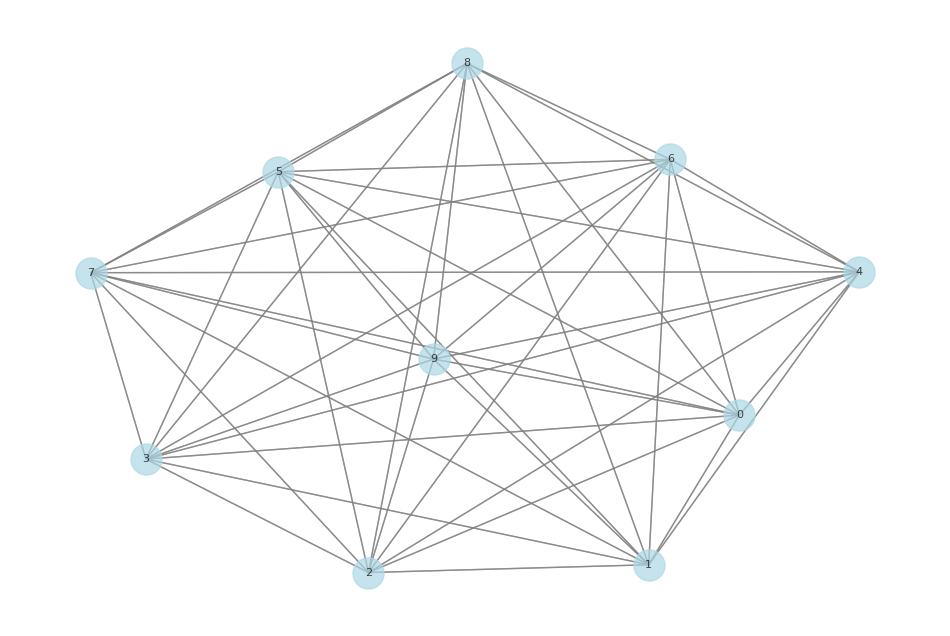

In [75]:
class CompleteGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes
        """
        self.graph = nx.complete_graph(n)


generator = CompleteGraph()
generator.generate_graph(10)
generator.visualise(node_labels=False)

## Weighted Graph

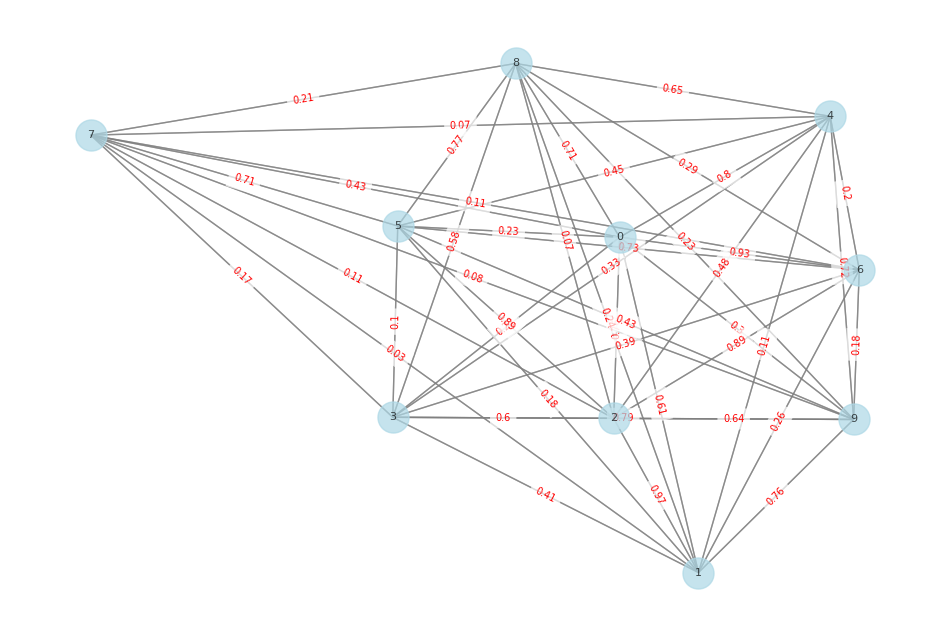

In [76]:
class WeightedGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes, with random weights
        """
        self.graph = nx.complete_graph(n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = WeightedGraph()
generator.generate_graph(10)
generator.visualise(node_labels=False)

## Full r-ary Tree Graph

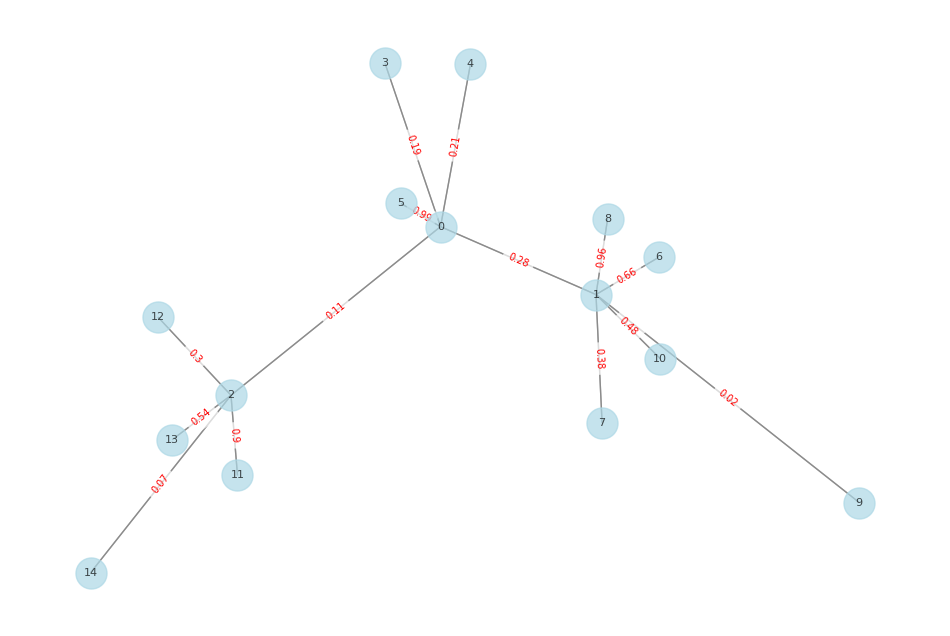

In [77]:
class FullRaryTree(GraphGenerator):
    def generate_graph(self, r, n):
        """
        Generates a full r-ary tree of n nodes with r branching factor, with random weights
        """
        self.graph = nx.full_rary_tree(r, n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = FullRaryTree()
generator.generate_graph(5, 15)
generator.visualise(node_labels=False)

## Erdos Renyi Graph

In [78]:
class ErdosRenyiGraph(GraphGenerator):
    def generate_graph(self, n, p):
        """
        Generates a random graph, also known as an Erdős-Rényi graph or a binomial graph, with random weights
        """
        self.graph = nx.erdos_renyi_graph(
            n,
            p,
            directed=True,
            seed=np.random.default_rng(),
        )

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = ErdosRenyiGraph()
generator.generate_graph(500, 0.3)
generator.serialise(path_to_networks, 'erdos_renyi_500')

Graph serialised to networks\erdos_renyi_500.pkl


## Erdos Renyi Graph with Non-Uniform Node Costs

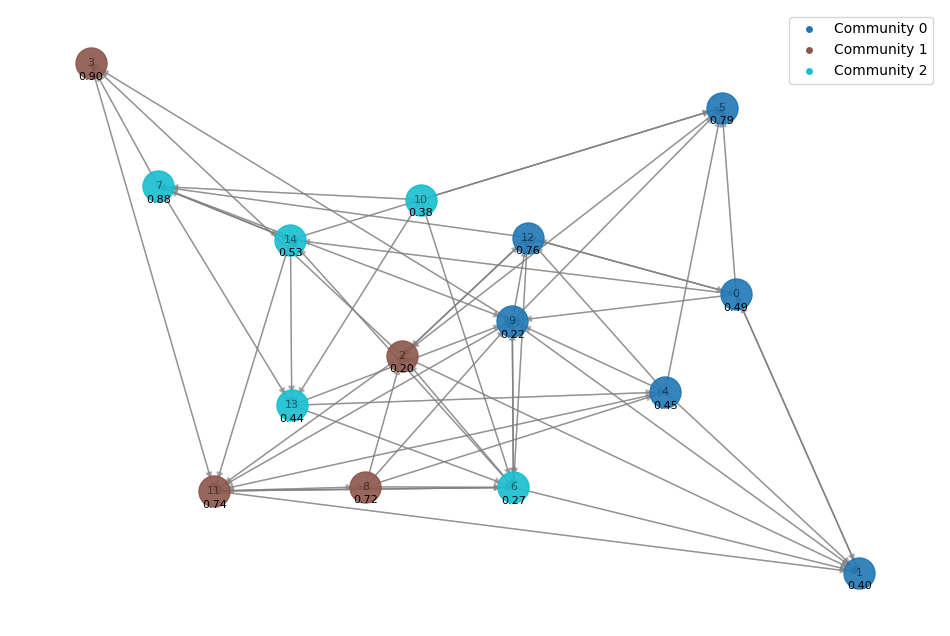

In [79]:
class NonUniformErdosRenyiGraph(GraphGenerator):
    def generate_graph(self, n, p):
        """
        Generates a random graph, also known as an Erdős-Rényi graph or a binomial graph, with random weights and non-uniform node costs.
        """
        self.graph = nx.erdos_renyi_graph(
            n,
            p,
            directed=True,
            seed=np.random.default_rng(),
        )

        self.node_costs = {
            node: np.random.uniform(0.1, 1.0)
            for node in self.graph.nodes()
        }

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i

generator = NonUniformErdosRenyiGraph()
generator.generate_graph(15, 0.3)
generator.visualise()

In [80]:
class BarbasiAlbertGraph(GraphGenerator):
    def generate_graph(self, n, m, num_communities=5):
        """
        Generates a Barbasi Albert Graph with non-uniform node costs and community structures
        """
        self.graph = nx.barabasi_albert_graph(
            n,
            m,
            seed=np.random.default_rng(),
        )

        self.node_costs = {
            node: np.random.uniform(0.1, 2.0)
            for node in self.graph.nodes()
        }

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i

generator = BarbasiAlbertGraph()
generator.generate_graph(1000, 3)
generator.serialise(path_to_networks, 'barbasi_albert_1000')

Graph serialised to networks\barbasi_albert_1000.pkl
